# Guide to Loading Data from Bench2Drive

## 1. Load necessary pkl files

In [15]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# Load pkl files
train_infos = pickle.load(open("../data/infos/b2d_infos_train.pkl", "rb"))
val_infos = pickle.load(open("../data/infos/b2d_infos_val.pkl", "rb"))
map_infos = pickle.load(open("../data/infos/b2d_map_infos.pkl", "rb"))

print(f"Number of train samples: {len(train_infos)}")
print(f"Number of val samples: {len(val_infos)}")
print(f"Number of towns in map: {len(map_infos)}")

print(type(map_infos))

Number of train samples: 1455
Number of val samples: 840
Number of towns in map: 11
<class 'dict'>


## 2. Multi-view image for each frame

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f1e16c71ee0>>
Traceback (most recent call last):
  File "/mnt/HDD2/iccv/miniconda3/envs/orion/lib/python3.8/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


KeyboardInterrupt: 

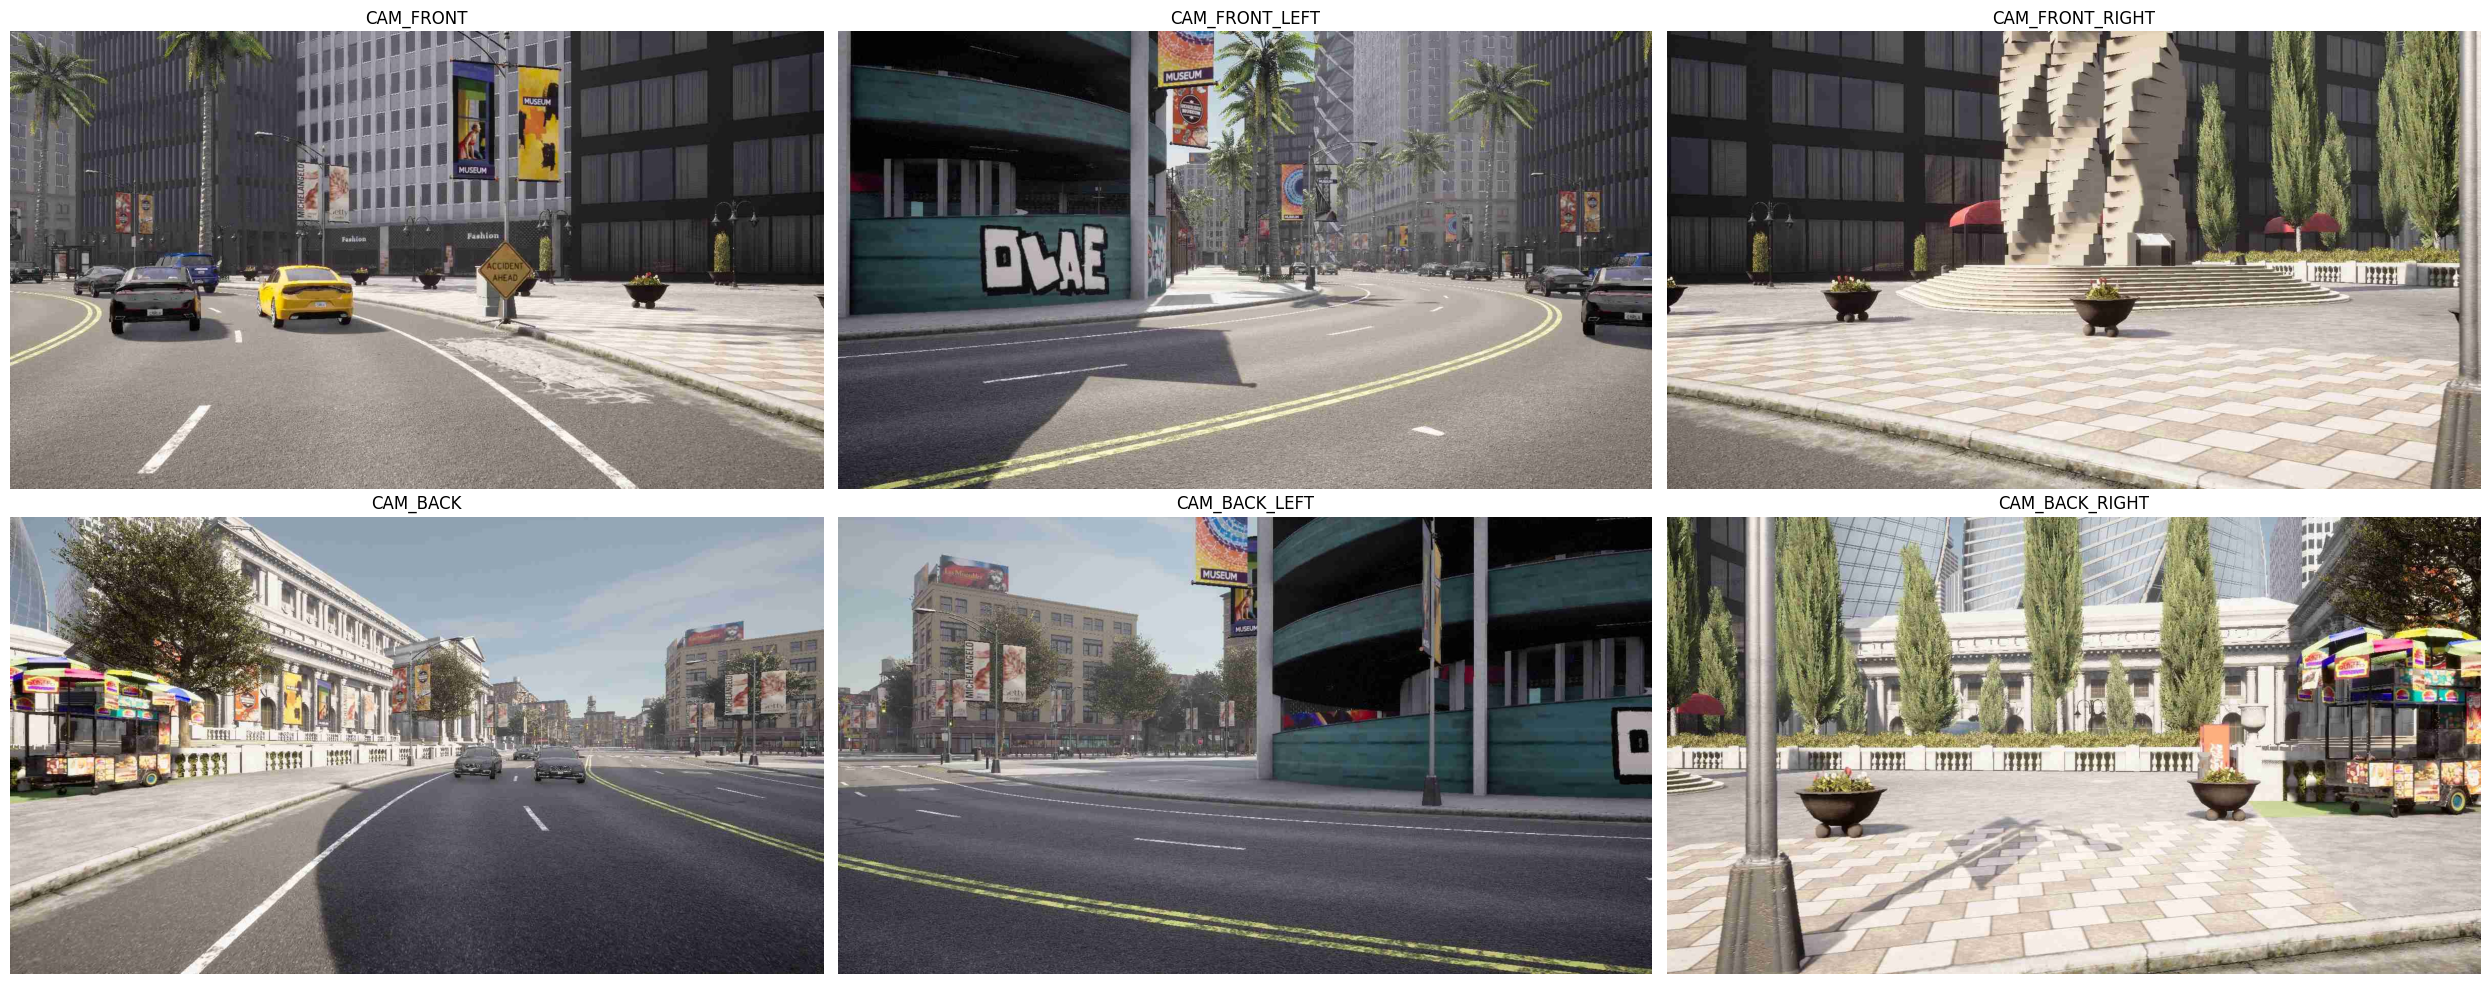

In [ ]:
from tqdm import tqdm

data_root = "bench2drive/"
multi_view_dir = "styleclips/multi-view-images/"

for sample in tqdm(train_infos, desc="Creating multi-view images"):

    scene_dir = os.path.join(multi_view_dir, sample['folder'])
    os.makedirs(scene_dir, exist_ok=True)

    cameras = ['CAM_FRONT', 'CAM_FRONT_LEFT', 'CAM_FRONT_RIGHT',
                   'CAM_BACK', 'CAM_BACK_LEFT', 'CAM_BACK_RIGHT']
    
    output_filename = f"{sample['frame_idx']:05d}.jpg"
    output_path = os.path.join(scene_dir, output_filename)


    # Create the composite image
    fig, axes = plt.subplots(2, 3, figsize=(25, 10))
    axes = axes.flatten()
    
    for idx, cam_name in enumerate(cameras):
        if cam_name in sample['sensors']:
            cam_info = sample['sensors'][cam_name]
            img_path = os.path.join(data_root, cam_info['data_path'])
            # print(f"image_path: {img_path}")
            try:
                img = Image.open(img_path)
                axes[idx].imshow(img)
                axes[idx].set_title(cam_name)
                axes[idx].axis('off')
            except FileNotFoundError:
                axes[idx].text(0.5, 0.5, f'{cam_name}\nFile not found',
                                ha='center', va='center')
                axes[idx].axis('off')
        else:
            axes[idx].text(0.5, 0.5, f'{cam_name}\nNot available',
                            ha='center', va='center')
            axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(output_path, bbox_inches='tight', dpi=100, format='jpg')
    plt.close(fig)

## 14. Create Clips for QwenVL Analysis

This section demonstrates how to create video clips for QwenVL driving style analysis.

**Sampling Configuration:**
- Clip length: 10 frames (5 seconds at 2Hz)
- Sample interval: 5 frames (from 10Hz original data)
- Sampling pattern: 
  - Clip 0: frames [0, 5, 10, 15, 20, 25, 30, 35, 40, 45]
  - Clip 1: frames [1, 6, 11, 16, 21, 26, 31, 36, 41, 46]
  - etc.

In [23]:
from collections import defaultdict
from typing import List, Dict, Any, Tuple, Optional
import json


class ClipGenerator:
    """Generate clips from Bench2Drive data for QwenVL analysis."""
    
    def __init__(
        self,
        data_infos: List,
        map_infos: Dict,
        data_root: str = "",
        clip_length: int = 10,          # Number of frames per clip
        sample_interval: int = 5,       # Frame interval (original 10Hz, sample at 2Hz -> interval=5)
        max_distance: float = 50.0,     # Max distance for map/object filtering
        multi_view_output_dir: str = "styleclips/multi-view-images",
    ):
        self.data_infos = data_infos
        self.map_infos = map_infos
        self.data_root = data_root
        self.clip_length = clip_length
        self.sample_interval = sample_interval
        self.max_distance = max_distance
        self.multi_view_output_dir = multi_view_output_dir
        
        # Create output directory if it doesn't exist
        os.makedirs(self.multi_view_output_dir, exist_ok=True)
        
        # Group frames by scene
        self.scene_frames = self._group_by_scene()
        
    def _group_by_scene(self) -> Dict[str, List[int]]:
        """Group frame indices by scene/folder."""
        scene_frames = defaultdict(list)
        for idx, info in enumerate(self.data_infos):
            scene_frames[info['folder']].append(idx)
        return dict(scene_frames)
    
    def get_clips_for_scene(self, scene_name: str) -> List[List[int]]:
        """
        Get all valid clips for a scene.
        
        Sampling pattern:
        - Clip starting at offset 0: frames [0, 5, 10, 15, 20, 25, 30, 35, 40, 45]
        - Clip starting at offset 1: frames [1, 6, 11, 16, 21, 26, 31, 36, 41, 46]
        - etc.
        """
        frame_indices = self.scene_frames[scene_name]
        num_frames = len(frame_indices)
        required_frames = (self.clip_length - 1) * self.sample_interval + 1
        
        clips = []
        
        # Only iterate over valid starting offsets
        for offset in range(num_frames - required_frames + 1):
            start = offset
            # Create clip with sampled frames
            clip_local_indices = [
                start + i * self.sample_interval 
                for i in range(self.clip_length)
            ]
            # Convert to global indices
            clip_global_indices = [frame_indices[i] for i in clip_local_indices]
            clips.append(clip_global_indices)
        
        return clips
    
    def get_all_clips(self) -> List[Tuple[str, List[int]]]:
        """Get all valid clips from all scenes."""
        all_clips = []
        for scene_name in self.scene_frames.keys():
            clips = self.get_clips_for_scene(scene_name)
            for clip in clips:
                all_clips.append((scene_name, clip))
        return all_clips
    
    def get_frame_info(self, frame_idx: int) -> Dict[str, Any]:
        """Get information for a single frame."""
        sample = self.data_infos[frame_idx]
        # print(sample)
        # Basic ego info
        print(sample['ego_translation'].tolist())
        ego_info = {
            'translation': sample['ego_translation'].tolist() if isinstance(sample['ego_translation'], np.ndarray) else sample['ego_translation'],
            'yaw': ((sample['ego_yaw'])),
            'velocity': ((sample['ego_vel'])),
            'command_near': ((sample['command_near'])),
            'command_far': ((sample['command_far'])) if 'command_far' in sample else None,
        }
       
        # # Object info (filter by valid objects)
        mask = sample['num_points'] != 0
        # print(f"in get frame ingo: mask: {mask}")
        objects = []
        for i, (box, name, obj_id) in enumerate(zip(
            sample['gt_boxes'][mask],
            sample['gt_names'][mask],
            sample['gt_ids'][mask]
        )):
            distance = np.sqrt(box[0]**2 + box[1]**2)
            if distance <= self.max_distance:
                objects.append({
                    'id': int((obj_id)),
                    'class': str(name),
                    'position': [(box[0]), (box[1]), (box[2])],
                    'size': [(box[3]), (box[4]), (box[5])],
                    'yaw': (box[6]),
                    'velocity': [(box[7]), (box[8])],
                    'distance': (distance),
                })
        
        
        return {
            'frame_idx': sample['frame_idx'],
            'ego': ego_info,
            'objects': objects,
        }
    
    def get_map_info_for_frame(self, frame_idx: int) -> Dict[str, Any]:
        """Get map information around the ego vehicle for a single frame."""
        sample = self.data_infos[frame_idx]
        town_name = sample['town_name']
        map_info = self.map_infos[town_name]
        
        world2lidar = np.array(sample['sensors']['LIDAR_TOP']['world2lidar'])
        ego_xy = np.linalg.inv(world2lidar)[0:2, 3]
        
        # Count nearby lanes and triggers
        nearby_lane_types = []
        for i in range(len(map_info['lane_sample_points'])):
            sample_points = map_info['lane_sample_points'][i]
            distance = np.linalg.norm(sample_points[:, 0:2] - ego_xy, axis=-1)
            if distance.min() < self.max_distance:
                nearby_lane_types.append(map_info['lane_types'][i])
        
        nearby_trigger_types = []
        for i in range(len(map_info['trigger_volumes_sample_points'])):
            sample_points = map_info['trigger_volumes_sample_points'][i]
            distance = np.linalg.norm(sample_points[0:2] - ego_xy, axis=-1)
            if distance.min() < self.max_distance:
                nearby_trigger_types.append(map_info['trigger_volumes_types'][i])
        
        return {
            'town_name': town_name,
            'num_lanes': len(nearby_lane_types),
            'num_triggers': len(nearby_trigger_types),
            'lane_types': list(set(nearby_lane_types)),
            'trigger_types': list(set(nearby_trigger_types)),
        }
    
    def _create_multi_view_image(self, sample: Dict, frame_idx: int, scene_name: str) -> str:
        """Create a composite multi-view image from all 6 cameras and save it."""
        cameras = ['CAM_FRONT', 'CAM_FRONT_LEFT', 'CAM_FRONT_RIGHT',
                   'CAM_BACK', 'CAM_BACK_LEFT', 'CAM_BACK_RIGHT']
        
        # Create scene subdirectory
        scene_dir = os.path.join(self.multi_view_output_dir, scene_name)
        os.makedirs(scene_dir, exist_ok=True)
        
        # Generate filename: {frame_idx:05d}.jpg (5 digits with zero padding)
        output_filename = f"{frame_idx:05d}.jpg"
        output_path = os.path.join(scene_dir, output_filename)
        
        # Check if already exists
        if os.path.exists(output_path):
            return output_path
        
        # Create the composite image
        fig, axes = plt.subplots(2, 3, figsize=(25, 10))
        axes = axes.flatten()
        
        for idx, cam_name in enumerate(cameras):
            if cam_name in sample['sensors']:
                cam_info = sample['sensors'][cam_name]
                img_path = os.path.join(self.data_root, cam_info['data_path'])
                print(f"image_path: {img_path}")
                try:
                    img = Image.open(img_path)
                    axes[idx].imshow(img)
                    axes[idx].set_title(cam_name)
                    axes[idx].axis('off')
                except FileNotFoundError:
                    axes[idx].text(0.5, 0.5, f'{cam_name}\nFile not found',
                                   ha='center', va='center')
                    axes[idx].axis('off')
            else:
                axes[idx].text(0.5, 0.5, f'{cam_name}\nNot available',
                               ha='center', va='center')
                axes[idx].axis('off')
        
        plt.tight_layout()
        plt.savefig(output_path, bbox_inches='tight', dpi=100, format='jpg')
        plt.close(fig)
        
        return output_path
    
    def get_image_paths_for_clip(self, clip_indices: List[int]) -> List[str]:
        """Get multi-view composite image file paths for a clip."""
        paths = []
        for frame_idx in clip_indices:
            sample = self.data_infos[frame_idx]
            scene_name = sample['folder']
            
            # Create multi-view composite image and get its path
            multi_view_path = self._create_multi_view_image(sample, frame_idx, scene_name)
            paths.append(multi_view_path)
        
        return paths
    
    def create_clip_data(self, scene_name: str, clip_indices: List[int]) -> Dict[str, Any]:
        """Create complete data dictionary for a clip."""
        # Get image paths
        video_paths = self.get_image_paths_for_clip(clip_indices) 
        
        # Get frame-by-frame info
    
        # frames_info = [self.get_frame_info(idx) for idx in clip_indices]
        frames_info = []
        for idx in clip_indices:
            
            try:
                frames_info.append(self.get_frame_info(idx))
            except Exception as e:
                print(f"[ERROR] get_frame_info failed at idx={idx}, type={type(e).__name__}, msg={e}")
                # 加上關鍵欄位檢查（如果 get_frame_info 裡抓得到 sample）
            
        
        # Get map info (from middle frame)
        middle_idx = clip_indices[len(clip_indices) // 2]
        map_info = self.get_map_info_for_frame(middle_idx)
        
        # Calculate statistics
        ego_velocities = [f['ego']['velocity'] for f in frames_info]
        ego_positions = [f['ego']['translation'] for f in frames_info]
        
        if len(ego_positions) >= 2:
            start_pos = np.array(ego_positions[0][:2])
            end_pos = np.array(ego_positions[-1][:2])
            total_displacement = float(np.linalg.norm(end_pos - start_pos))
        else:
            total_displacement = 0.0
        
        return {
            'scene_name': scene_name,
            'clip_frame_indices': clip_indices,
            'num_frames': len(clip_indices),
            'sample_fps': 2,
            'duration_seconds': (len(clip_indices)) / 2.0,
            'video_paths': video_paths,
            'frames': frames_info,
            'map_info': map_info,
            'statistics': {
                'mean_velocity': float(np.mean(ego_velocities)),
                'max_velocity': float(np.max(ego_velocities)),
                'min_velocity': float(np.min(ego_velocities)),
                'velocity_std': float(np.std(ego_velocities)),
                'total_displacement': total_displacement,
                'total_objects_seen': sum(len(f['objects']) for f in frames_info),
                'unique_object_ids': len(set(obj['id'] for f in frames_info for obj in f['objects'])),
            }
        }
    
    def format_as_qwenvl_message(
        self,
        clip_data: Dict[str, Any],
        prompt: str = "According to the driving record, what do you think about the driving style? conservative, aggressive, or normal? why?",
        include_context: bool = True,
    ) -> Dict[str, Any]:
        """Format clip data as QwenVL message."""
        video_paths = clip_data['video_paths']
        video_paths = [f"bench2drive/{p.lstrip('/')}" for p in video_paths if p is not None]
        
        context_str = ""
        if include_context:
            frames_info = clip_data['frames']
            stats = clip_data['statistics']
            map_info = clip_data['map_info']
            
            context_str = f"""Driving context:
- Duration: {clip_data['duration_seconds']:.1f} seconds
- Average speed: {stats['mean_velocity']:.1f} m/s ({stats['mean_velocity']*3.6:.1f} km/h)
- Speed range: {stats['min_velocity']:.1f} - {stats['max_velocity']:.1f} m/s
- Total displacement: {stats['total_displacement']:.1f} meters
- Objects encountered: {stats['unique_object_ids']} unique objects
- Location: {map_info['town_name']}
- Road features: {', '.join(map_info['lane_types']) if map_info['lane_types'] else 'unknown'}
- Traffic controls: {', '.join(map_info['trigger_types']) if map_info['trigger_types'] else 'none nearby'}
- Detail frames info: {frames_info}

"""
        
        return {
            "role": "user",
            "content": [
                {
                    "type": "video",
                    "video": video_paths,
                    "sample_fps": str(clip_data['sample_fps']),
                },
                {
                    "type": "text",
                    "text": context_str,
                },
                {
                    "type": "text",
                    "text": prompt,
                }
            ],
        }

print("ClipGenerator class defined successfully!")

ClipGenerator class defined successfully!


In [24]:
# Initialize the clip generator
generator = ClipGenerator(
    data_infos=train_infos,
    map_infos=map_infos,
    data_root="bench2drive/",
    clip_length=10,       # 10 frames per clip (5 seconds at 2Hz)
    sample_interval=5,    # Sample every 5 frames (2Hz from 10Hz original)
)

print(f"Number of scenes: {len(generator.scene_frames)}")

# Count total clips
total_clips = sum(len(generator.get_clips_for_scene(s)) for s in generator.scene_frames.keys())
print(f"Total possible clips: {total_clips}")

# Show example for first scene
first_scene = list(generator.scene_frames.keys())[2]
scene_clips = generator.get_clips_for_scene(first_scene)
print(f"\nScene '{first_scene}':")
print(f"  Total frames in scene: {len(generator.scene_frames[first_scene])}")
print(f"  Number of clips: {len(scene_clips)}")
print(f"\n  First 348 clips (frame indices):")
for i, clip in enumerate(scene_clips):
    local_indices = [generator.scene_frames[first_scene].index(idx) for idx in clip]
    print(f"    Clip {i}: local frames {local_indices}")


Number of scenes: 6
Total possible clips: 1185

Scene 'v1/DynamicObjectCrossing_Town02_Route13_Weather6':
  Total frames in scene: 214
  Number of clips: 169

  First 348 clips (frame indices):
    Clip 0: local frames [0, 5, 10, 15, 20, 25, 30, 35, 40, 45]
    Clip 1: local frames [1, 6, 11, 16, 21, 26, 31, 36, 41, 46]
    Clip 2: local frames [2, 7, 12, 17, 22, 27, 32, 37, 42, 47]
    Clip 3: local frames [3, 8, 13, 18, 23, 28, 33, 38, 43, 48]
    Clip 4: local frames [4, 9, 14, 19, 24, 29, 34, 39, 44, 49]
    Clip 5: local frames [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
    Clip 6: local frames [6, 11, 16, 21, 26, 31, 36, 41, 46, 51]
    Clip 7: local frames [7, 12, 17, 22, 27, 32, 37, 42, 47, 52]
    Clip 8: local frames [8, 13, 18, 23, 28, 33, 38, 43, 48, 53]
    Clip 9: local frames [9, 14, 19, 24, 29, 34, 39, 44, 49, 54]
    Clip 10: local frames [10, 15, 20, 25, 30, 35, 40, 45, 50, 55]
    Clip 11: local frames [11, 16, 21, 26, 31, 36, 41, 46, 51, 56]
    Clip 12: local frames [

In [25]:
# Create and examine a single clip
first_scene = list(generator.scene_frames.keys())[0]
first_clip_indices = generator.get_clips_for_scene(first_scene)[0]

print(f"Creating clip from scene: {first_scene}")
print(f"Frame indices: {first_clip_indices}")

# Create clip data
clip_data = generator.create_clip_data(first_scene, first_clip_indices)

print(f"\n{'='*60}")
print("Clip Data Summary")
print(f"{'='*60}")
print(f"Scene: {clip_data['scene_name']}")
print(f"Number of frames: {clip_data['num_frames']}")
print(f"Duration: {clip_data['duration_seconds']} seconds")
print(f"Sample FPS: {clip_data['sample_fps']}")

print(f"\n--- Statistics ---")
for key, value in clip_data['statistics'].items():
    if isinstance(value, float):
        print(f"  {key}: {value:.2f}")
    else:
        print(f"  {key}: {value}")

print(f"\n--- Map Info ---")
for key, value in clip_data['map_info'].items():
    print(f"  {key}: {value}")

print(f"\n--- Frame-by-frame Ego Info ---")
for i, frame in enumerate(clip_data['frames']):
    print(frame)
    # ego = frame['ego']
    # print(f"  Frame {i}: vel={ego['velocity']:.2f} m/s, yaw={ego['yaw']:.2f}, objects={len(frame['objects'])}")


Creating clip from scene: v1/ConstructionObstacle_Town05_Route68_Weather8
Frame indices: [0, 5, 10, 15, 20, 25, 30, 35, 40, 45]
[154.0557302097703, -170.75681915409936, 0.0]
[153.93554759045992, -170.20459268902292, 0.0]
[152.4922037005287, -171.0756275794241, 0.0]
[150.42576365194117, -172.5583135781262, 0.0]
[146.4413454278469, -175.14312007021724, 0.0]
[143.39042324368594, -177.37542799377155, 0.0]
[139.34631993839386, -179.4452026080042, 0.0]
[135.87020528342623, -179.94421851933305, 0.0]
[131.89225236292086, -183.00183523646888, 0.0]
[127.35413637702425, -183.45688197180016, 0.0]

Clip Data Summary
Scene: v1/ConstructionObstacle_Town05_Route68_Weather8
Number of frames: 10
Duration: 5.0 seconds
Sample FPS: 2

--- Statistics ---
  mean_velocity: 2.06
  max_velocity: 8.93
  min_velocity: 0.00
  velocity_std: 3.45
  total_displacement: 29.57
  total_objects_seen: 150
  unique_object_ids: 25

--- Map Info ---
  town_name: Town05
  num_lanes: 28
  num_triggers: 0
  lane_types: ['Center

In [13]:
# Format as QwenVL message
qwenvl_message = generator.format_as_qwenvl_message(
    clip_data,
    prompt="According to the driving record, what do you think about the driving style? conservative, aggressive, or normal? why?",
    include_context=True,
)

print("QwenVL Message Format:")
print("="*60)
print(json.dumps(qwenvl_message, indent=2))


QwenVL Message Format:
{
  "role": "user",
  "content": [
    {
      "type": "video",
      "video": [
        "bench2drive/mnt/HDD1/iccv/orion_workspace/Orion/data/styleclips/multi-view-images/v1/ConstructionObstacle_Town05_Route68_Weather8/0.jpg",
        "bench2drive/mnt/HDD1/iccv/orion_workspace/Orion/data/styleclips/multi-view-images/v1/ConstructionObstacle_Town05_Route68_Weather8/5.jpg",
        "bench2drive/mnt/HDD1/iccv/orion_workspace/Orion/data/styleclips/multi-view-images/v1/ConstructionObstacle_Town05_Route68_Weather8/10.jpg",
        "bench2drive/mnt/HDD1/iccv/orion_workspace/Orion/data/styleclips/multi-view-images/v1/ConstructionObstacle_Town05_Route68_Weather8/15.jpg",
        "bench2drive/mnt/HDD1/iccv/orion_workspace/Orion/data/styleclips/multi-view-images/v1/ConstructionObstacle_Town05_Route68_Weather8/20.jpg",
        "bench2drive/mnt/HDD1/iccv/orion_workspace/Orion/data/styleclips/multi-view-images/v1/ConstructionObstacle_Town05_Route68_Weather8/25.jpg",
        "b

Creating clips:   0%|          | 0/50 [00:00<?, ?it/s]

[154.0557302097703, -170.75681915409936, 0.0]
[153.93554759045992, -170.20459268902292, 0.0]
[152.4922037005287, -171.0756275794241, 0.0]
[150.42576365194117, -172.5583135781262, 0.0]
[146.4413454278469, -175.14312007021724, 0.0]
[143.39042324368594, -177.37542799377155, 0.0]
[139.34631993839386, -179.4452026080042, 0.0]
[135.87020528342623, -179.94421851933305, 0.0]
[131.89225236292086, -183.00183523646888, 0.0]
[127.35413637702425, -183.45688197180016, 0.0]
image_path: bench2drive/v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_front/00001.jpg
image_path: bench2drive/v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_front_left/00001.jpg
image_path: bench2drive/v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_front_right/00001.jpg
image_path: bench2drive/v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_back/00001.jpg
image_path: bench2drive/v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_back_left/00001.jpg
image_path: bench2drive/v1/

Creating clips:   4%|▍         | 2/50 [00:13<05:22,  6.72s/it]

[153.2107805735894, -170.85918373392497, 0.0]
[153.41690483510973, -170.2652848919246, 0.0]
[152.44160247208922, -171.22426650600028, 0.0]
[149.1821723997692, -174.01346025979856, 0.0]
[146.18526254224102, -175.97902107115144, 0.0]
[142.09739990128642, -177.63155896514348, 0.0]
[139.58650271384798, -178.88299227744218, 0.0]
[134.3811369017116, -181.15988700899894, 0.0]
[130.5246404506889, -182.84853824062174, 0.0]
[127.55364697643562, -184.06603998981217, 0.0]
image_path: bench2drive/v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_front/00002.jpg
image_path: bench2drive/v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_front_left/00002.jpg
image_path: bench2drive/v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_front_right/00002.jpg
image_path: bench2drive/v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_back/00002.jpg
image_path: bench2drive/v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_back_left/00002.jpg
image_path: bench2drive/v1

Creating clips:   6%|▌         | 3/50 [00:26<07:25,  9.49s/it]

[153.52659512184084, -170.36469040613855, 0.0]
[152.4000304822284, -170.56484607595536, 0.0]
[151.3532191444997, -171.04469035669305, 0.0]
[148.89602101775313, -174.326838030335, 0.0]
[146.0002050743288, -174.34260433039688, 0.0]
[142.58683612850135, -178.21104926155814, 0.0]
[138.62798450064466, -179.05643269016525, 0.0]
[135.00968887027562, -180.98819836091295, 0.0]
[130.45906753758248, -182.77236226571463, 0.0]
[126.00684571058136, -183.03581080702907, 0.0]
image_path: bench2drive/v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_front/00003.jpg
image_path: bench2drive/v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_front_left/00003.jpg
image_path: bench2drive/v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_front_right/00003.jpg
image_path: bench2drive/v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_back/00003.jpg
image_path: bench2drive/v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_back_left/00003.jpg
image_path: bench2drive/v1

Creating clips:   8%|▊         | 4/50 [00:40<08:24, 10.97s/it]

[152.818015798366, -171.16047806244708, 0.0]
[153.57790503982397, -169.54763654847466, 0.0]
[151.80079117901442, -171.97239293158347, 0.0]
[148.76386279036925, -173.07196216835445, 0.0]
[145.0375221800957, -175.6963939531644, 0.0]
[140.55989244292812, -178.47696675964775, 0.0]
[137.18992850176176, -180.22820535216752, 0.0]
[132.85395134987164, -182.28488147164202, 0.0]
[129.37710892197498, -182.64488113818152, 0.0]
[126.25506651102812, -185.13907572516197, 0.0]
image_path: bench2drive/v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_front/00004.jpg
image_path: bench2drive/v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_front_left/00004.jpg
image_path: bench2drive/v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_front_right/00004.jpg
image_path: bench2drive/v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_back/00004.jpg
image_path: bench2drive/v1/ConstructionObstacle_Town05_Route68_Weather8/camera/rgb_back_left/00004.jpg
image_path: bench2drive/v

Creating clips:   8%|▊         | 4/50 [00:49<09:25, 12.30s/it]


KeyboardInterrupt: 

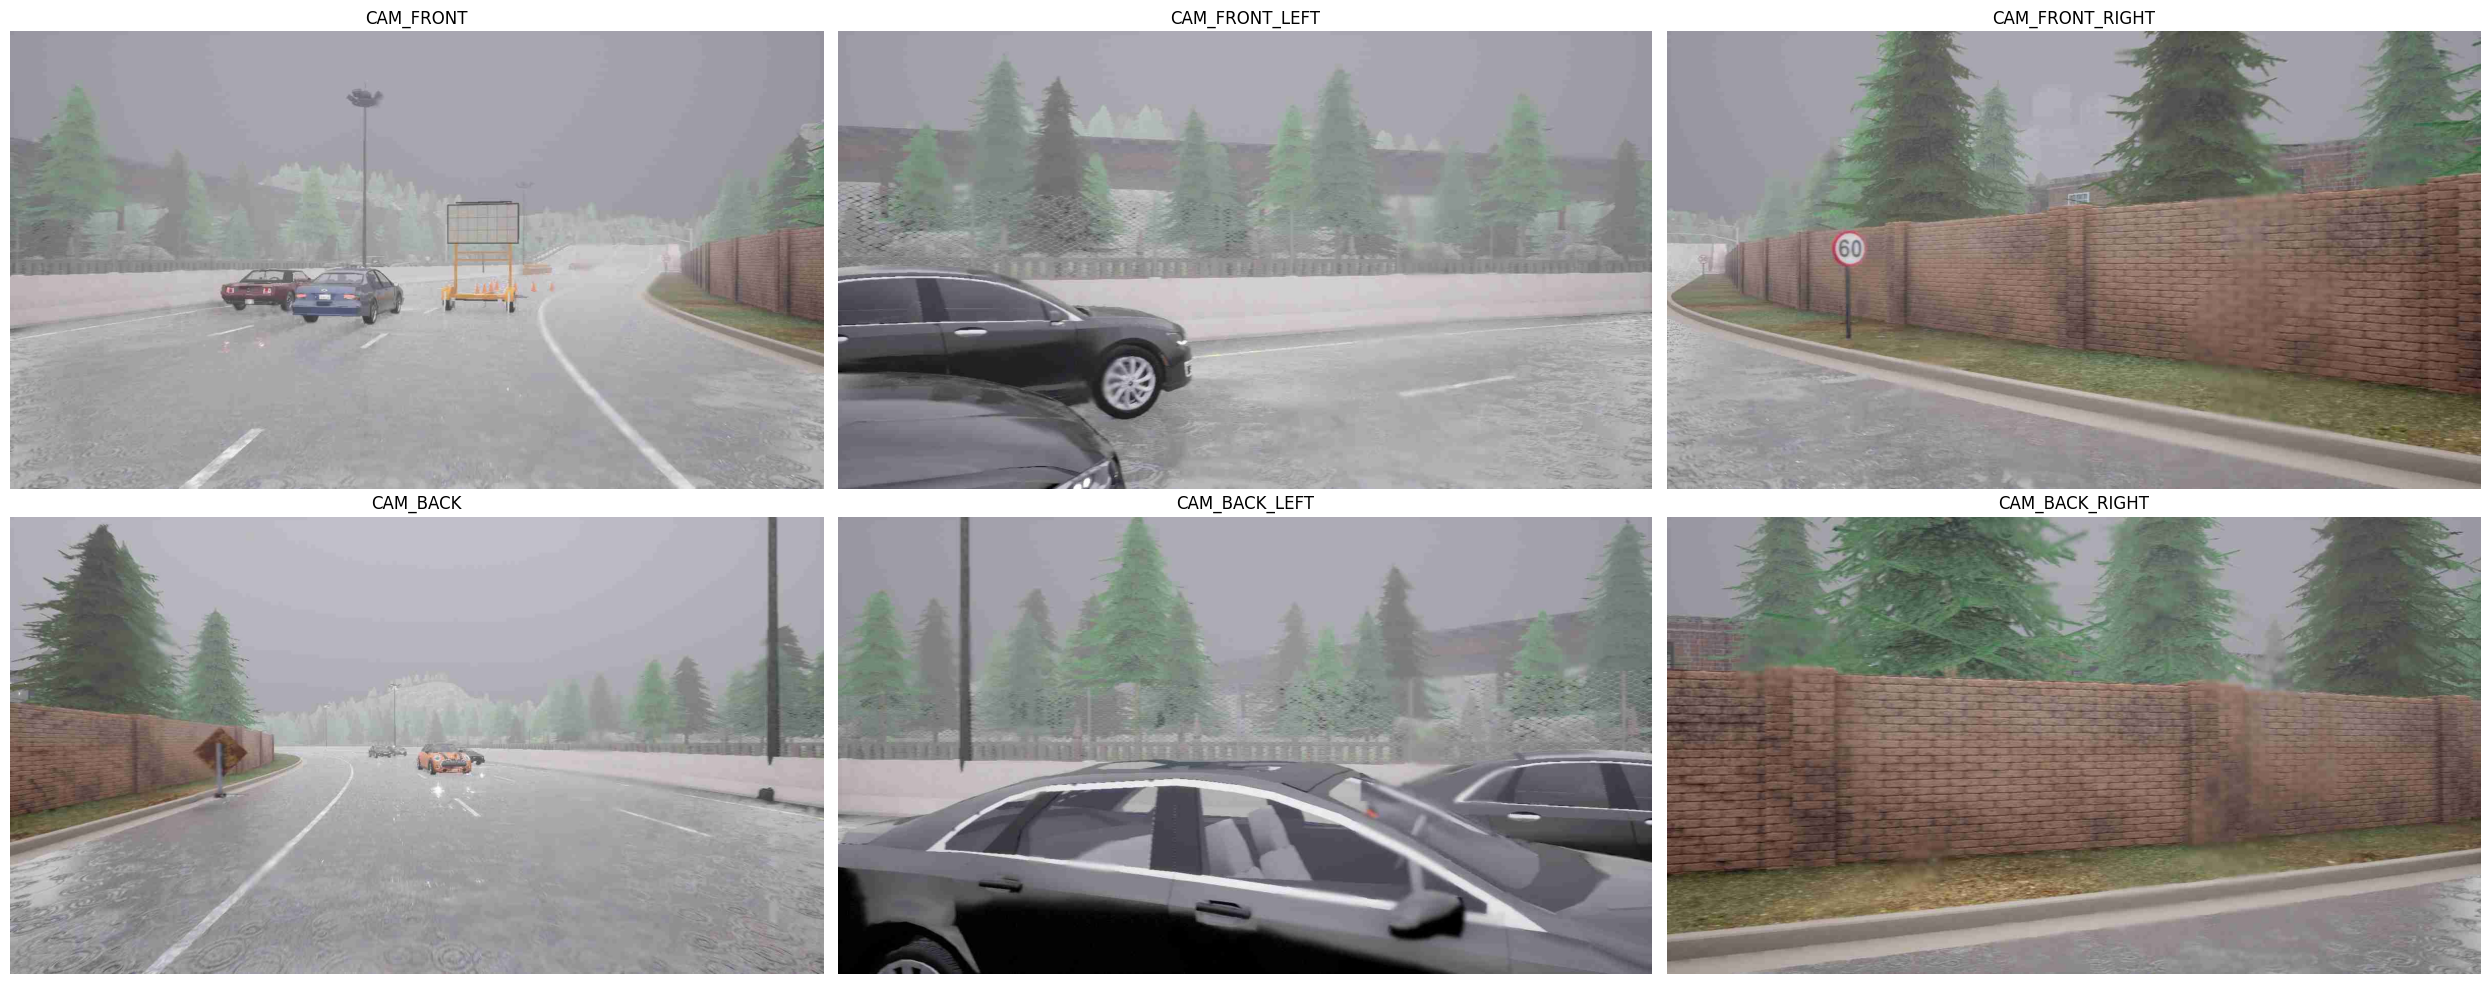

In [26]:
# Generate all clips and save to JSON
# This may take a while depending on dataset size

from tqdm import tqdm

def create_qwenvl_dataset(
    generator: ClipGenerator,
    output_path: str,
    max_clips: Optional[int] = None,
    prompt: str = "According to the driving record, what do you think about the driving style? conservative, aggressive, or normal? why?",
    include_context: bool = True,
):
    """Create full QwenVL dataset from all clips."""
    all_clips = generator.get_all_clips()
    
    if max_clips is not None:
        all_clips = all_clips[:max_clips]
    
    messages = []
    clip_metadata = []
    
    for scene_name, clip_indices in tqdm(all_clips, desc="Creating clips"):
        clip_data = generator.create_clip_data(scene_name, clip_indices)
        
        message = generator.format_as_qwenvl_message(
            clip_data, 
            prompt=prompt,
            include_context=include_context,
        )
        
        messages.append(message)
        clip_metadata.append({
            'scene_name': scene_name,
            'frame_indices': clip_indices,
            'statistics': clip_data['statistics'],
            'map_info': clip_data['map_info'],
        })
    
    # Save to file
    output_data = {
        'messages': messages,
        'metadata': clip_metadata,
        'config': {
            'clip_length': generator.clip_length,
            'sample_interval': generator.sample_interval,
            'sample_fps': 2,
            'max_distance': generator.max_distance,
        }
    }
    
    with open(output_path, 'w') as f:
        json.dump(output_data, f, indent=2)
    
    print(f"Saved {len(messages)} clips to {output_path}")
    return messages, clip_metadata

# Create dataset with first 50 clips as demo
messages, metadata = create_qwenvl_dataset(
    generator,
    output_path="styleclips/qwenvl_clips_demo.json",
    max_clips=50,
    include_context=True,
)

print(f"\nGenerated {len(messages)} QwenVL messages")


## Usage Notes

### Clip Structure

Each clip contains:
- **10 frames** sampled at 2Hz (5 seconds total)
- **Video paths**: File paths to CAM_FRONT images
- **Frame info**: Ego vehicle state and detected objects per frame
- **Map info**: Lane types, traffic controls in the area
- **Statistics**: Velocity stats, displacement, object counts

### QwenVL Message Format

```python
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "video",
                "video": [
                    "file:///path/to/frame1.jpg",
                    "file:///path/to/frame2.jpg",
                    ...
                ],
                "sample_fps": "2",
            },
            {
                "type": "text", 
                "text": "Driving context:\n- Duration: 4.5 seconds\n..."
            },
        ],
    }
]
```

### Sampling Pattern

With `clip_length=10` and `sample_interval=5`:
- Clip offset 0: frames [0, 5, 10, 15, 20, 25, 30, 35, 40, 45]
- Clip offset 1: frames [1, 6, 11, 16, 21, 26, 31, 36, 41, 46]
- Clip offset 2: frames [2, 7, 12, 17, 22, 27, 32, 37, 42, 47]
- Clip offset 3: frames [3, 8, 13, 18, 23, 28, 33, 38, 43, 48]
- Clip offset 4: frames [4, 9, 14, 19, 24, 29, 34, 39, 44, 49]

### Generate Full Dataset

```python
# For full dataset (may take time)
messages, metadata = create_qwenvl_dataset(
    generator,
    output_path="styleclips/qwenvl_clips_full.json",
    max_clips=None,  # Process all clips
    include_context=True,
)
```